In [1]:
import sys
sys.path.append('../')

In [2]:
import pandas as pd
import random
from tqdm import tqdm
from os.path import join as pjoin
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
root = '../data/filtered'

In [4]:
xPath = pjoin(root, 'X.h5')
yPath = pjoin(root, 'Y.h5')

X = pd.read_hdf(xPath)
Y = pd.read_hdf(yPath)

In [6]:
well_names = list(X.UWI.unique())

In [12]:
well_name = random.choice(well_names)

In [88]:
well_data = X[X.UWI == well_name]
well_data_y = Y[X.UWI == well_name]

In [90]:
def shaliness_index(GR, GR_clean, GR_shale):
    return (GR - GR_clean) / (GR_shale - GR_clean)

from sklearn.cluster import KMeans
import numpy as np
from matplotlib import pyplot as plt

In [91]:
first_derivative = well_data.GR[::3].diff()

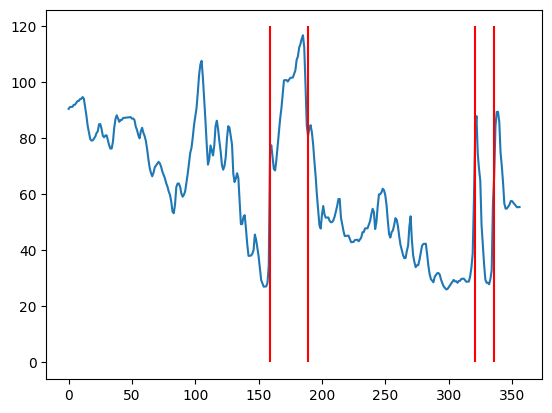

In [92]:
threshold = 30  # Adjust this threshold as needed

major_inflection_points = np.where(np.abs(first_derivative) >= threshold)[0]
well_data.GR.reset_index(drop=True).plot()
plt.vlines(major_inflection_points*3, 0, 120, colors='r')

In [93]:
start, end = 0, 0
for i in range(len(major_inflection_points)+1):
    if i<=len(major_inflection_points)-1:
        end = major_inflection_points[i]*3
        gr_zone = well_data.GR[start:end]
        vsh_zone = shaliness_index(gr_zone, gr_zone.quantile(0.01), gr_zone.quantile(0.99))
        well_data.loc[gr_zone.index, 'VSH_ZONE'] = vsh_zone
        start = end
    else:
        end = len(well_data.GR)
        gr_zone = well_data.GR[start:end]
        vsh_zone = shaliness_index(gr_zone, gr_zone.quantile(0.01), gr_zone.quantile(0.99))
        well_data.loc[gr_zone.index, 'VSH_ZONE'] = vsh_zone
        start = end

/tmp/ipykernel_68321/2503625424.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  well_data.loc[gr_zone.index, 'VSH_ZONE'] = vsh_zone


In [75]:
major_inflection_points*3

array([159, 189, 321, 336])

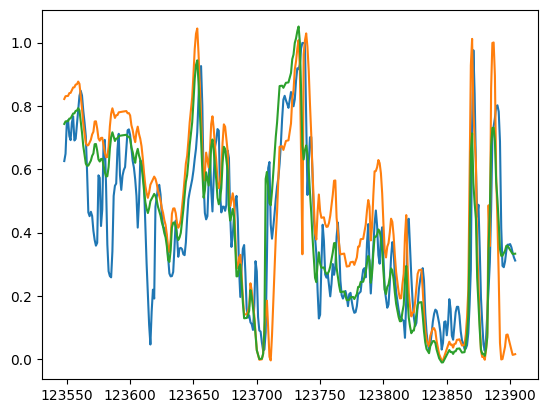

In [95]:
plt.plot(well_data.VSH)
plt.plot(well_data.VSH_ZONE)
plt.plot(shaliness_index(well_data.GR, well_data.GR.quantile(0.01), well_data.GR.quantile(0.99)))

<Axes: xlabel='VSH', ylabel='Density'>

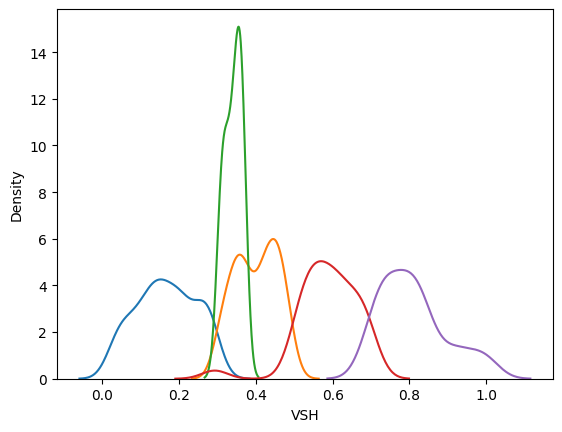

In [113]:
import seaborn as sns
sns.kdeplot(well_data[well_data_y == 0].VSH)
sns.kdeplot(well_data[well_data_y == 1].VSH)
sns.kdeplot(well_data[well_data_y == 2].VSH)
sns.kdeplot(well_data[well_data_y == 3].VSH)
sns.kdeplot(well_data[well_data_y == 4].VSH)